In [1]:
!pip install matplotlib scikit-learn

# Connecting to google drive to load the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Organising data into train and test folders

In [3]:
import os
import shutil
import random

base_dir = "/content/drive/MyDrive/dataset"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")

split_ratio = 0.8
random.seed(42)


os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

In [4]:
classes = [
    d for d in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, d))
    and d not in ["train", "val"]
]

for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    images = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]

    random.shuffle(images)
    split_idx = int(len(images) * split_ratio)

    train_images = images[:split_idx]
    val_images   = images[split_idx:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_images:
        src = os.path.join(cls_path, img)
        dst = os.path.join(train_dir, cls, img)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

    for img in val_images:
        src = os.path.join(cls_path, img)
        dst = os.path.join(val_dir, cls, img)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

print("✅ Dataset split completed safely.")

✅ Dataset split completed safely.


# Importing necessary libraries

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision import models
from tqdm import tqdm
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt
import random
import json
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Custom dataloader class and transforms

In [6]:

train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])



test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])])

In [7]:
class Car_Dataset(Dataset):
  def __init__(self, dir_path, transform=None):
    self.data = ImageFolder(dir_path, transform=transform)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    return self.data[index]

In [8]:
train_path = "/content/drive/MyDrive/dataset/train"
test_path  = "/content/drive/MyDrive/dataset/val"


train_set = Car_Dataset(dir_path=train_path, transform=train_transforms)
test_set  = Car_Dataset(dir_path=test_path, transform=test_transforms)

In [9]:
class_to_idx = train_set.data.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
idx_to_class

{0: 'F_Breakage',
 1: 'F_Crushed',
 2: 'F_Normal',
 3: 'R_Breakage',
 4: 'R_Crushed',
 5: 'R_Normal'}

# Visualising the train test split

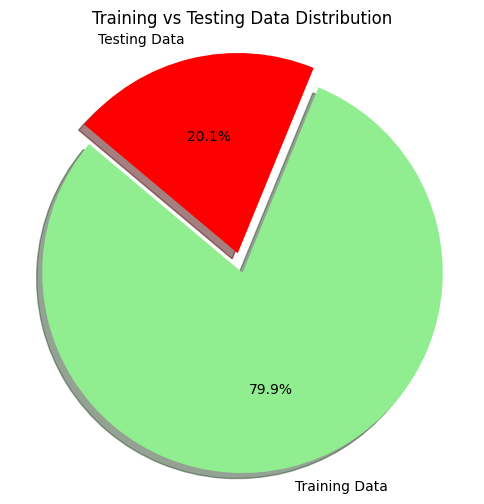

In [11]:
labels = ['Training Data', 'Testing Data']
sizes  = [len(train_set), len(test_set)]
colors = ['lightgreen', 'red']
explode = (0.1, 0)
plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Training vs Testing Data Distribution')
plt.axis('equal')
plt.show()

# Ploting the image distribution across the classes

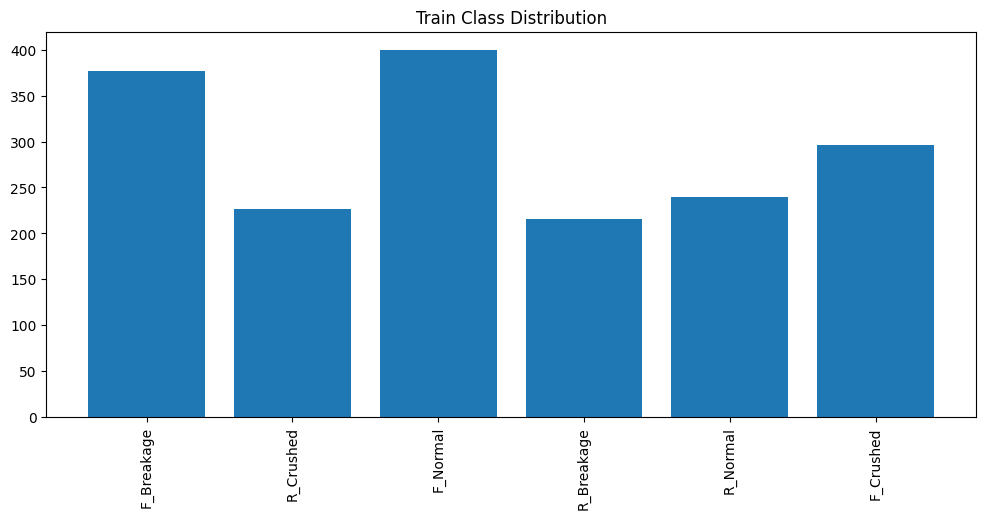

In [12]:
def plot_class_distribution(data_path):
    classes = os.listdir(data_path)
    counts = []

    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        if os.path.isdir(cls_path):
            counts.append(len(os.listdir(cls_path)))

    plt.figure(figsize=(12,5))
    plt.bar(classes, counts)
    plt.xticks(rotation=90)
    plt.title("Train Class Distribution")
    plt.show()

plot_class_distribution("/content/drive/MyDrive/dataset/train")

In [13]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True)

eval_loader = DataLoader(test_set, batch_size=128, num_workers=8, pin_memory=True, persistent_workers=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Initializing the model
- Again using same technique as deit transformer training only classifier and last 2 layers

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
class Car_Classifier_Resnet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = models.resnet18(weights="DEFAULT")

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer3.parameters():
            param.requires_grad = True

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Again using different LR for classifier and unfreezed layers

In [16]:
model = Car_Classifier_Resnet(num_classes=len(class_to_idx)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {"params": model.model.layer3.parameters(), "lr": 1e-5},
    {"params": model.model.layer4.parameters(), "lr": 1e-5},
    {"params": model.model.fc.parameters(), "lr": 1e-4}
])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


# Code for early stopping

In [17]:
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Training function

In [18]:
def train_model(model, epochs, train_loader, eval_loader, optimizer, criterion, device, patience=None, checkpoint_model_name=None):

    print("Starting training...")
    print(f"Total epochs: {epochs}")
    print(f"Training on device: {device}")
    print("-"*70)

    early_stopping = EarlyStopping(patience=patience, min_delta=0.001)

    train_losses, train_accuracy = [], []
    eval_losses, eval_accuracies = [], []

    best_loss = float('inf')
    for epoch in range(epochs):

        # ------------------------- TRAIN -------------------------
        model.train()
        running_loss, total, correct = 0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)
            logits = outputs

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            total += labels.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracy.append(train_acc)

        # ------------------------- VALIDATION -------------------------
        model.eval()
        ev_running_loss, ev_total, ev_correct = 0, 0, 0

        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in tqdm(eval_loader, desc=f"Epoch {epoch+1} Validation"):
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                logits = outputs

                loss = criterion(logits, labels)

                ev_running_loss += loss.item()
                ev_total += labels.size(0)

                preds = torch.argmax(logits, dim=1)
                ev_correct += (preds == labels).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        eval_loss = ev_running_loss / len(eval_loader)
        eval_acc = 100 * ev_correct / ev_total

        eval_losses.append(eval_loss)
        eval_accuracies.append(eval_acc)

        print(f"Results | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {eval_loss:.4f}, Val Acc: {eval_acc:.2f}%")
        print("-"*70)

        # ------------------------- SAVE BEST MODEL -------------------------
        if eval_loss < best_loss:
            best_loss = eval_loss
            os.makedirs("checkpoints", exist_ok=True)

            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'loss': eval_loss
            }, f"checkpoints/{checkpoint_model_name}.pt")

            print("Best model saved!")

        # ------------------------- EARLY STOPPING -------------------------
        early_stopping(eval_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return train_losses, train_accuracy, eval_losses, eval_accuracies, all_preds, all_labels

# Training model

In [19]:
train_losses, train_accuracy, eval_losses, eval_accuracies, all_preds, all_labels = train_model(model=model,
                                           epochs=100,
                                           train_loader=train_loader,
                                           eval_loader=eval_loader,
                                           optimizer=optimizer,
                                           criterion=criterion,
                                           patience=5,
                                           device=device,
                                           checkpoint_model_name='best_resnet_model')

Starting training...
Total epochs: 100
Training on device: cuda
----------------------------------------------------------------------


Epoch 1 Training:   0%|          | 0/14 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1 Validation: 100%|██████████| 4/4 [00:53<00:00, 13.49s/it]


Results | Train Loss: 1.8566, Train Acc: 18.52% | Val Loss: 1.7227, Val Acc: 29.25%
----------------------------------------------------------------------
Best model saved!


Epoch 2 Validation: 100%|██████████| 4/4 [00:04<00:00,  1.21s/it]


Results | Train Loss: 1.7067, Train Acc: 28.32% | Val Loss: 1.6105, Val Acc: 36.96%
----------------------------------------------------------------------
Best model saved!


...

Results | Train Loss: 0.4049, Train Acc: 82.85% | Val Loss: 0.6283, Val Acc: 74.15%
----------------------------------------------------------------------


Epoch 44 Validation: 100%|██████████| 4/4 [00:06<00:00,  1.65s/it]


Results | Train Loss: 0.4163, Train Acc: 82.34% | Val Loss: 0.6243, Val Acc: 74.83%
----------------------------------------------------------------------


Epoch 45 Validation: 100%|██████████| 4/4 [00:06<00:00,  1.66s/it]

Results | Train Loss: 0.3678, Train Acc: 84.67% | Val Loss: 0.6274, Val Acc: 75.28%
----------------------------------------------------------------------
Early stopping triggered at epoch 45


# Plotting the accuracy and loss

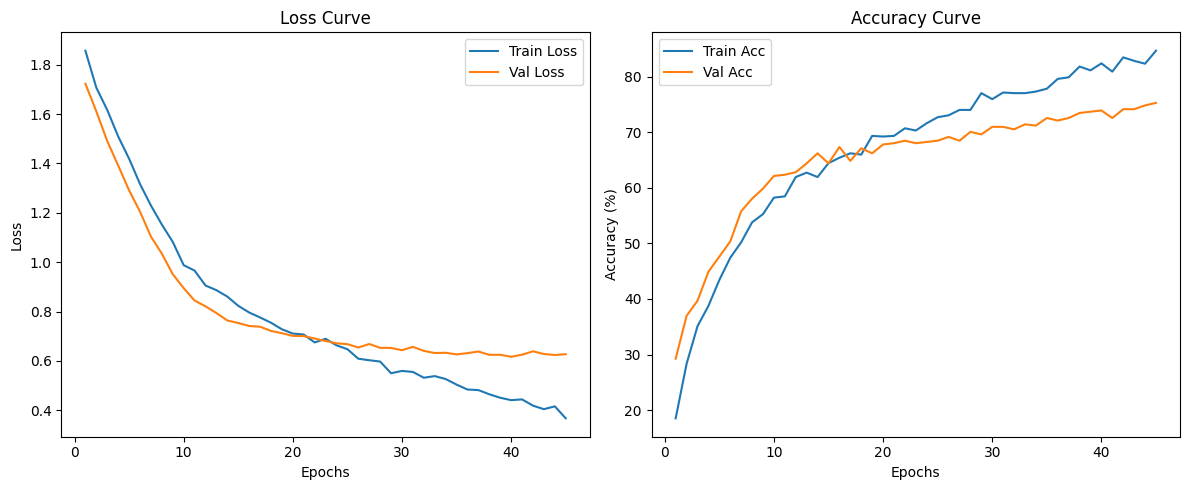

In [20]:
def plot_training_curves(train_losses, eval_losses, train_acc, eval_acc):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, eval_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, eval_acc, label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(
    train_losses,
    eval_losses,
    train_accuracy,
    eval_accuracies
)

# Plotting confusion matrix

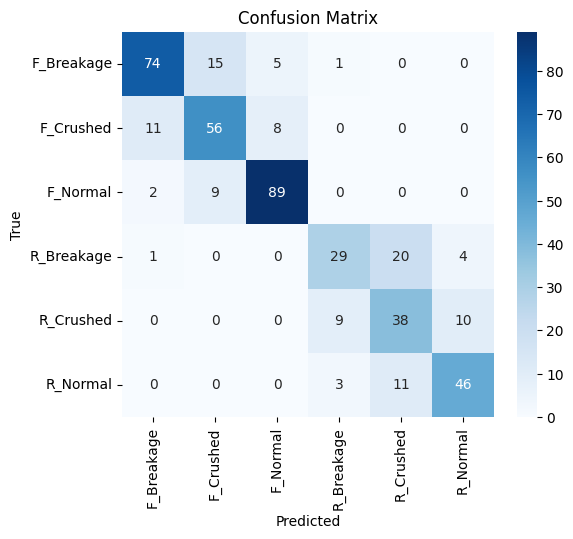

In [21]:
def plot_confusion_matrix_normalized(all_labels, all_preds):
  class_names = train_set.data.classes
  cm = confusion_matrix(all_labels, all_preds)
  plt.figure(figsize=(6, 5))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix")
  plt.show()

plot_confusion_matrix_normalized(all_labels, all_preds)

# Classification report

In [22]:
def print_classification_report(all_labels, all_preds, class_names=None):
    class_names = train_set.data.classes
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
    print(report)
print_classification_report(all_labels, all_preds)

              precision    recall  f1-score   support

  F_Breakage       0.84      0.78      0.81        95
   F_Crushed       0.70      0.75      0.72        75
    F_Normal       0.87      0.89      0.88       100
  R_Breakage       0.69      0.54      0.60        54
   R_Crushed       0.55      0.67      0.60        57
    R_Normal       0.77      0.77      0.77        60

    accuracy                           0.75       441
   macro avg       0.74      0.73      0.73       441
weighted avg       0.76      0.75      0.75       441

